In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/raw/amazon_sales_revenue_dataset.csv")
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,23.176
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,60.520
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,39.664
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,63.232
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,40.336


In [4]:
print("datasate info ")
print("--"*45)
print("--"*45)


print(df.info())


print("--"*45)
print("--"*45)
print("dataset description")
print(df.describe())

datasate info 
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-nul

In [5]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue', 'profit'],
      dtype='object')

In [6]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
profit              0
dtype: int64

- Revenue by Category

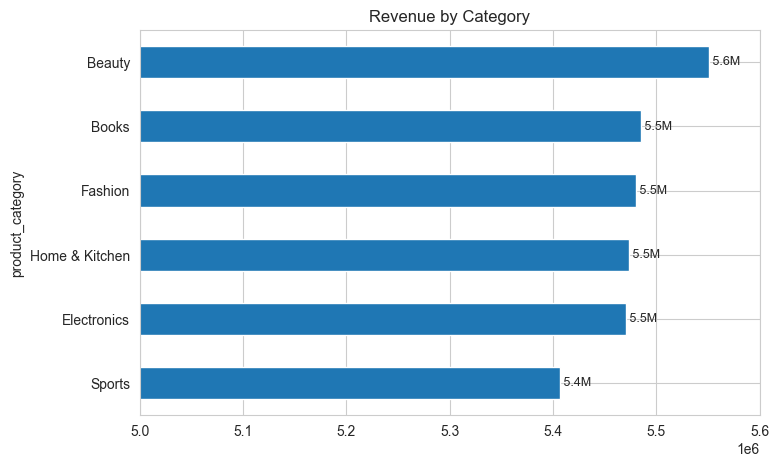

In [15]:
import matplotlib.ticker as ticker

category_revenue = df.groupby("product_category")["total_revenue"].sum().sort_values()

category_revenue.plot(kind="barh", figsize=(8,5))
for i, v in enumerate(category_revenue.values):
    plt.text(v, i, f" {v/1e6:.1f}M", va='center', fontsize=9)

plt.xlim(5.00e6, 5.60e6)  # 👈 ye add kar

plt.title("Revenue by Category")

plt.savefig("../images/category_revenue.png", dpi=300, bbox_inches='tight')

plt.show()

- Monthly trend

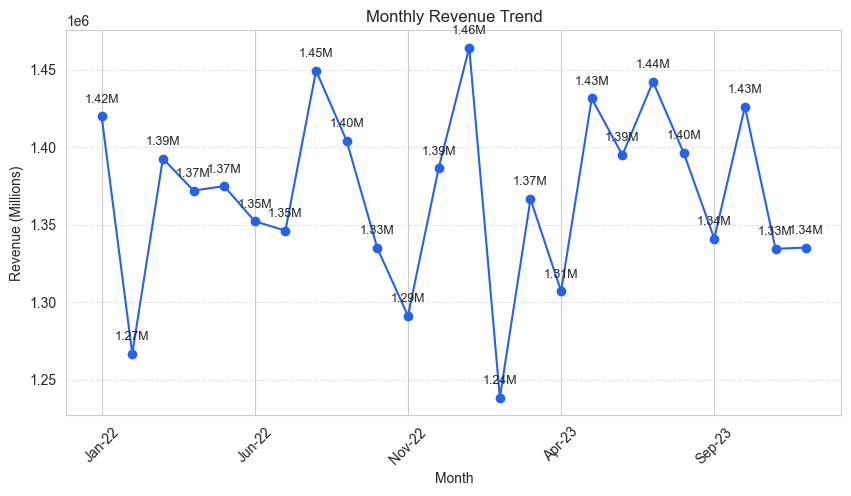

In [31]:
import matplotlib.pyplot as plt

df["order_date"] = pd.to_datetime(df["order_date"])

monthly = df.groupby(df["order_date"].dt.to_period("M"))["total_revenue"].sum()

monthly.index = monthly.index.strftime("%b-%y")

monthly.plot(figsize=(10,5), color="#2563EB", marker="o")

# ✅ correct loop
for i, v in enumerate(monthly.values):
    plt.text(i, v + 9000, f"{v/1e6:.2f}M", ha='center', fontsize=9)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Millions)")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("../images/monthly_revenue.png", dpi=300, bbox_inches='tight')
plt.show()

- Region Analysis

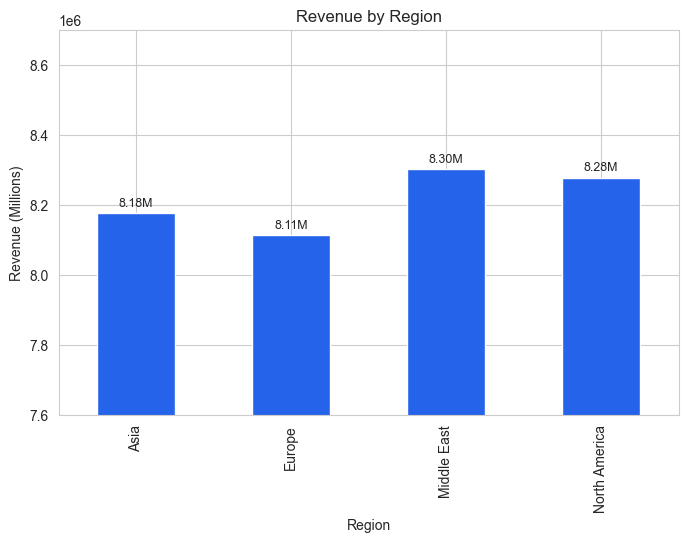

In [41]:
region = df.groupby("customer_region")["total_revenue"].sum()

region.plot(kind="bar", figsize=(8,5), color="#2563EB")

# correct text placement
for i, v in enumerate(region.values):
    plt.text(i, v + 20000, f"{v/1e6:.2f}M", ha='center', fontsize=9)

plt.ylim(7.6e6, 8.7e6)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (Millions)")
plt.savefig("../images/region_analysis.png", dpi=300, bbox_inches='tight')

plt.show()

- Correlation Matrix

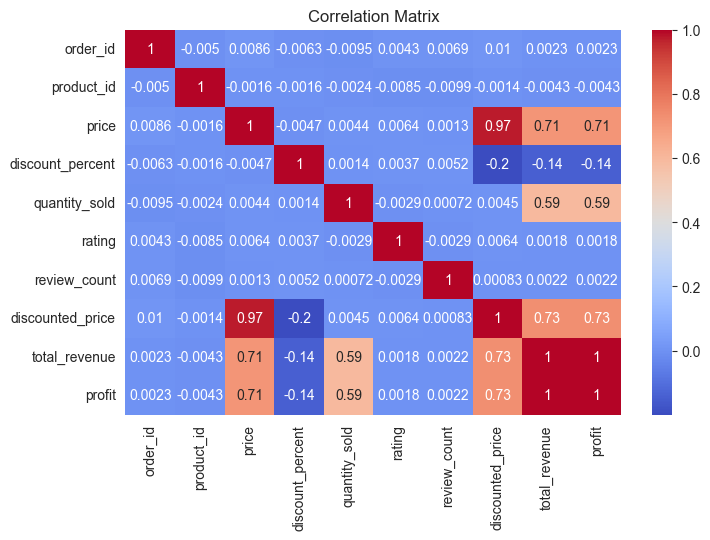

In [42]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.savefig("../images/correlation_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

- 🔹 5. Discount Impact

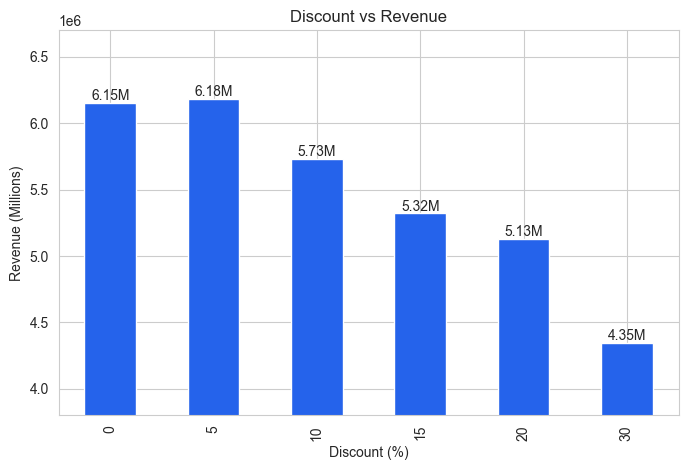

In [55]:
plt.figure(figsize=(8,5))

discount_rev = df.groupby("discount_percent")["total_revenue"].sum().sort_index()

discount_rev.plot(kind="bar", color="#2563EB")

for i, v in enumerate(discount_rev.values):
    plt.text(i, v + 20000, f"{v/1e6:.2f}M", ha='center')

plt.ylim(3.8e6, 6.7e6)

plt.title("Discount vs Revenue")
plt.xlabel("Discount (%)")
plt.ylabel("Revenue (Millions)")
plt.savefig("../images/Discount Impact.png", dpi=300, bbox_inches='tight')

plt.show()

- 🟢 6. Rating Distribution

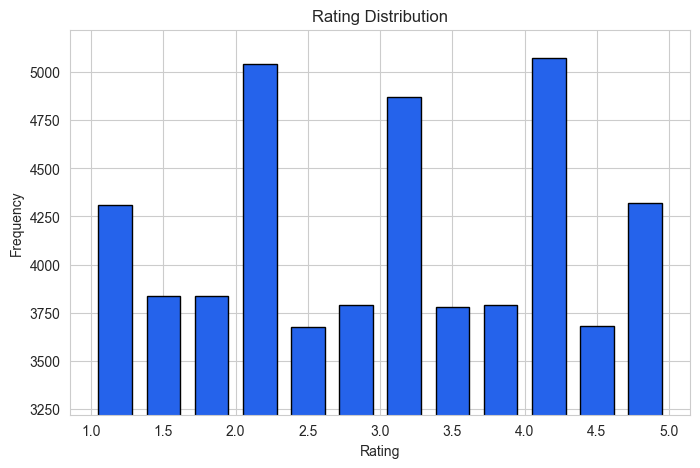

In [70]:
plt.figure(figsize=(8,5))

df["rating"].plot(kind="hist", bins=12, color="#2563EB", rwidth = 0.7, edgecolor = 'black')

plt.ylim(3.22e3 , 5.22e3)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.savefig("../images/rating_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

- 🟢 7. Orders by Category

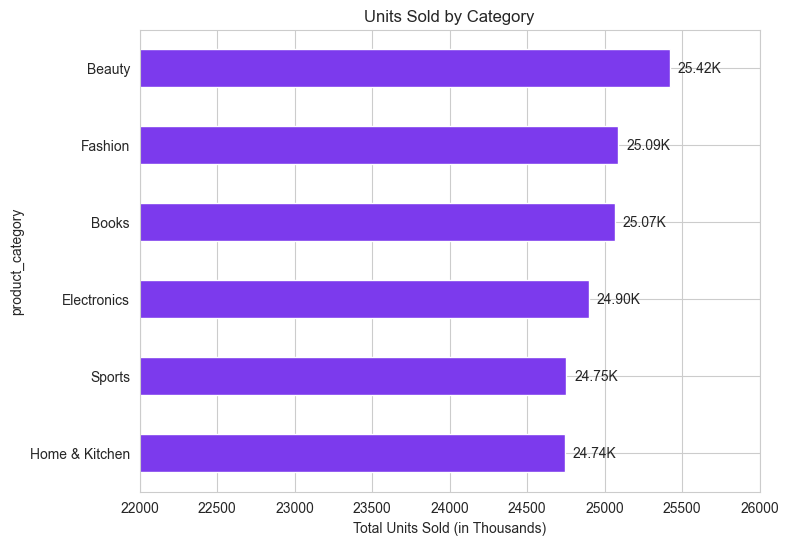

In [81]:
plt.figure(figsize=(8,6))

order_cat = df.groupby("product_category")["quantity_sold"].sum().sort_values()

order_cat.plot(kind="barh", color="#7C3AED")

for i, v in enumerate(order_cat.values):
    plt.text(v + 50, i, f"{v/1e3:.2f}K", va='center')  

plt.xlim(22e3, 26e3)

plt.title("Units Sold by Category")
plt.xlabel("Total Units Sold (in Thousands)")  
plt.savefig("../images/units_by_category.png", dpi=300, bbox_inches='tight')

plt.show()

- 🟢 8. Profit vs Revenue

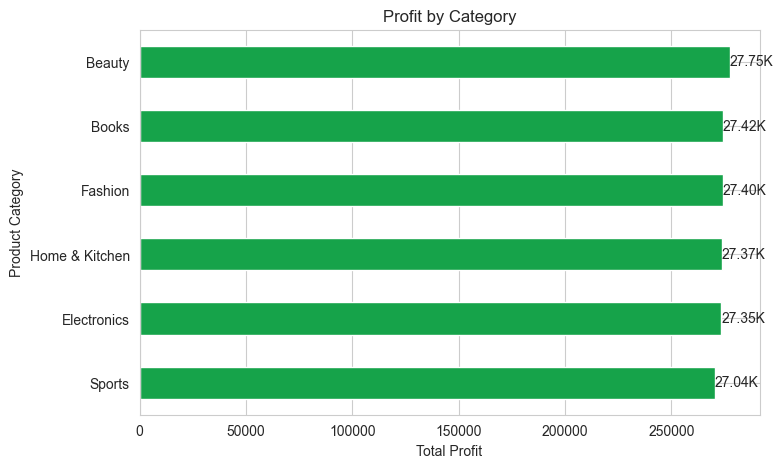

In [108]:
plt.figure(figsize=(8,5))

profit_cat = df.groupby("product_category")["profit"].sum().sort_values()

profit_cat.plot(kind="barh", color="#16A34A")

for i, v in enumerate(profit_cat.values):
    plt.text(v + 5, i, f"{v/1e4:.2f}K", va='center')

plt.title("Profit by Category")
plt.xlabel("Total Profit")
plt.ylabel("Product Category")
plt.savefig("../images/revenue_vs_profit_percent.png", dpi=300, bbox_inches='tight')
plt.show()

- 🟡 9. Payment Method Count

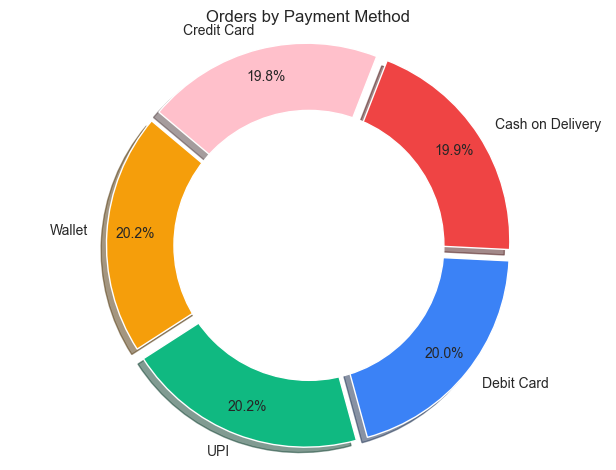

In [109]:

counts = df["payment_method"].value_counts()
plt.pie(
    counts,
    labels= counts.index,
    autopct='%1.1f%%',
    startangle= 140,
    colors=["#F59E0B", "#10B981", "#3B82F6", "#EF4444","#FFC0CB"],
        shadow=True, 
        pctdistance=0.85,
        explode=[0.05] * len(counts))

centre_circle = plt.Circle((0,0), 0.70 , fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.axis('equal')
plt.title('Orders by Payment Method')
plt.savefig("../images/payment_method.png", dpi=300)
plt.tight_layout()